In [23]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from pykalman import KalmanFilter
from  xgboost import XGBRegressor
import optuna
import shap
from  sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error

In [ ]:
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print("Path to dataset files:", path)
print('\n',os.listdir(path=path))

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3

 ['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [ ]:
files = os.listdir(path)
data_pool = {}

for filename in files:
    if filename.endswith('.csv'):
        full_path = os.path.join(path, filename)
        temp_df = pd.read_csv(full_path, header=0)
        
        if len(temp_df.columns) == 2:

            dataset_name = os.path.splitext(filename)[0]
            temp_df.columns = ['ds', 'y']
            
            kf = KalmanFilter(initial_state_mean=0, n_dim_obs=1)
            measurements = temp_df['y'].ffill().bfill().values
            state_means, _ = kf.filter(measurements)
        
            temp_df['y_kalman'] = state_means    
            data_pool[dataset_name] = temp_df
            
            print(f"✅ {dataset_name} lüğətə əlavə edildi.")


✅ AEP_hourly lüğətə əlavə edildi.
✅ COMED_hourly lüğətə əlavə edildi.
✅ DAYTON_hourly lüğətə əlavə edildi.
✅ DEOK_hourly lüğətə əlavə edildi.
✅ DOM_hourly lüğətə əlavə edildi.
✅ DUQ_hourly lüğətə əlavə edildi.
✅ EKPC_hourly lüğətə əlavə edildi.
✅ FE_hourly lüğətə əlavə edildi.
✅ NI_hourly lüğətə əlavə edildi.
✅ PJME_hourly lüğətə əlavə edildi.
✅ PJMW_hourly lüğətə əlavə edildi.
✅ PJM_Load_hourly lüğətə əlavə edildi.


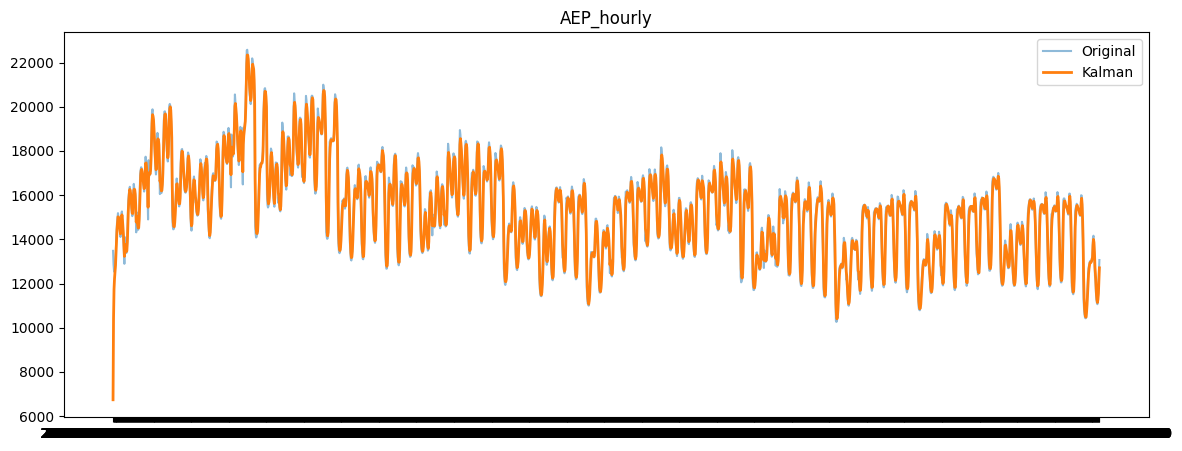

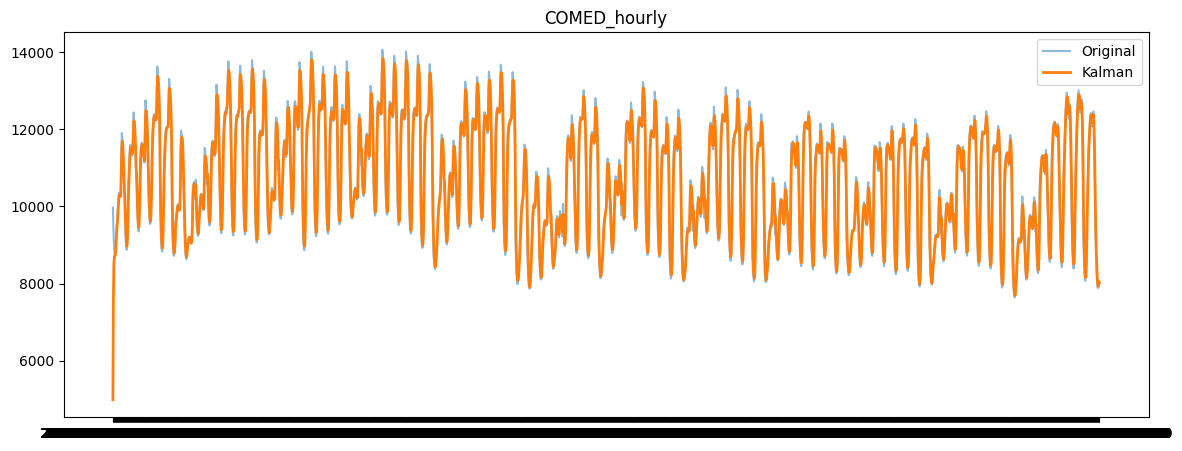

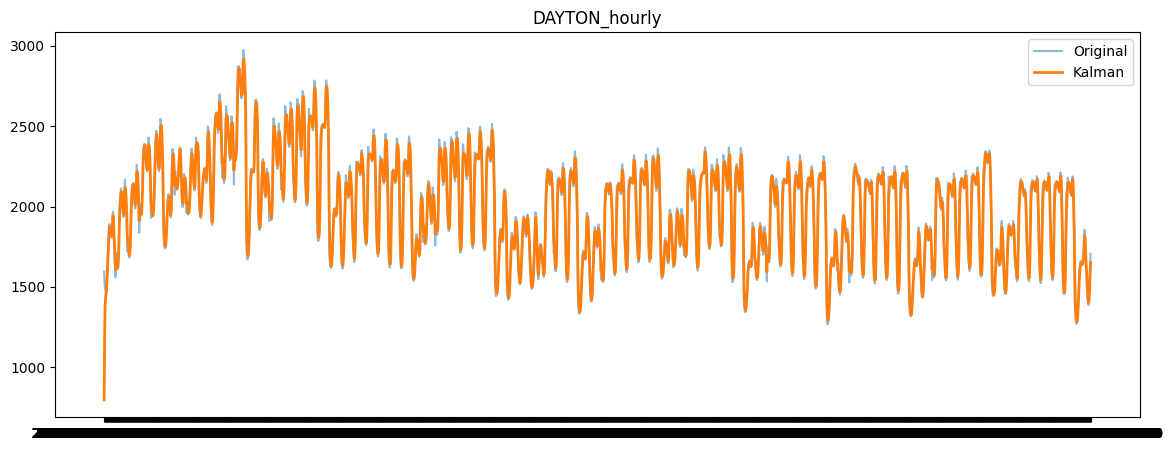

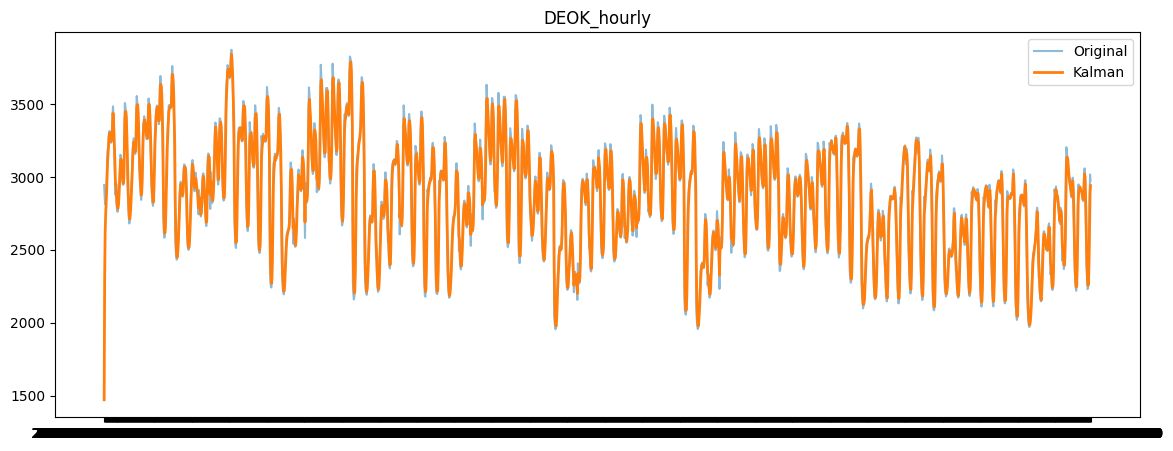

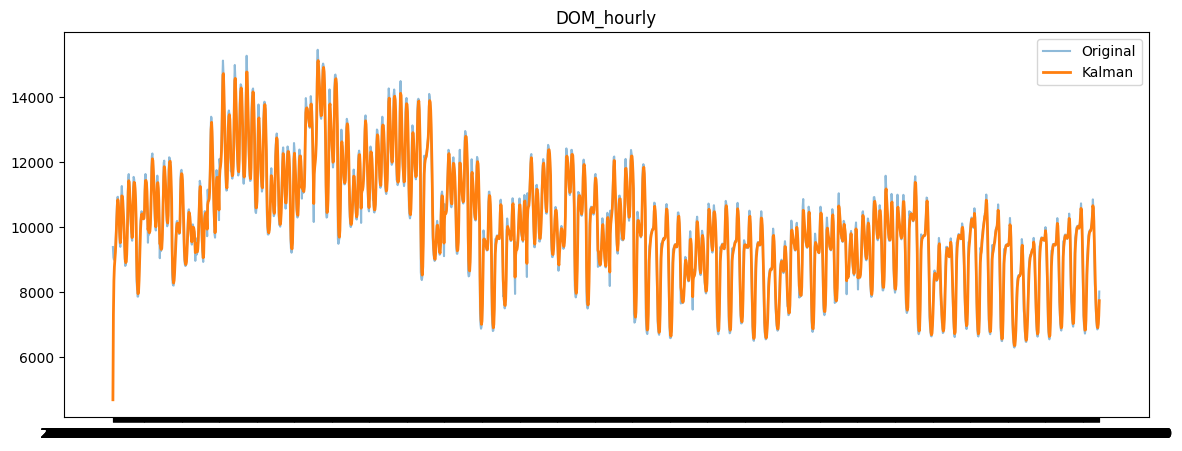

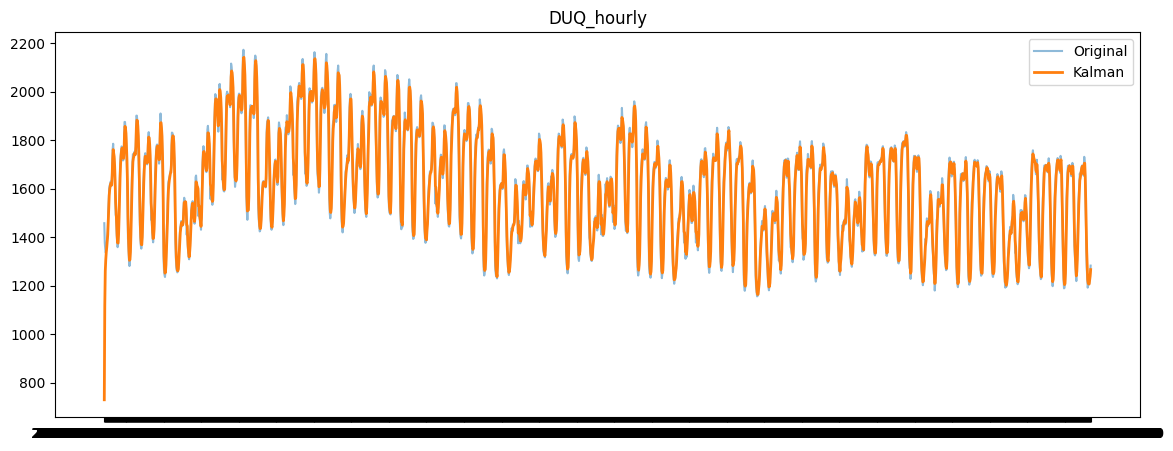

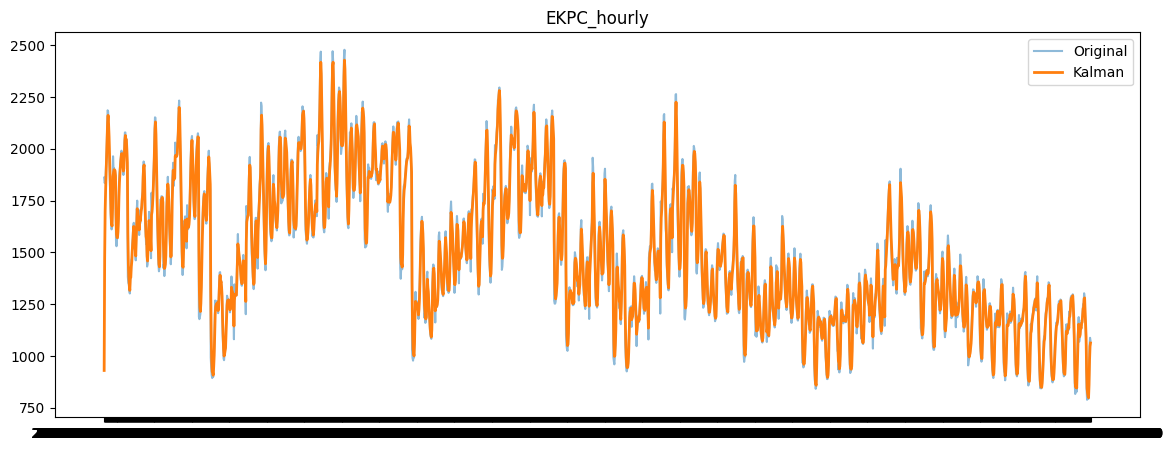

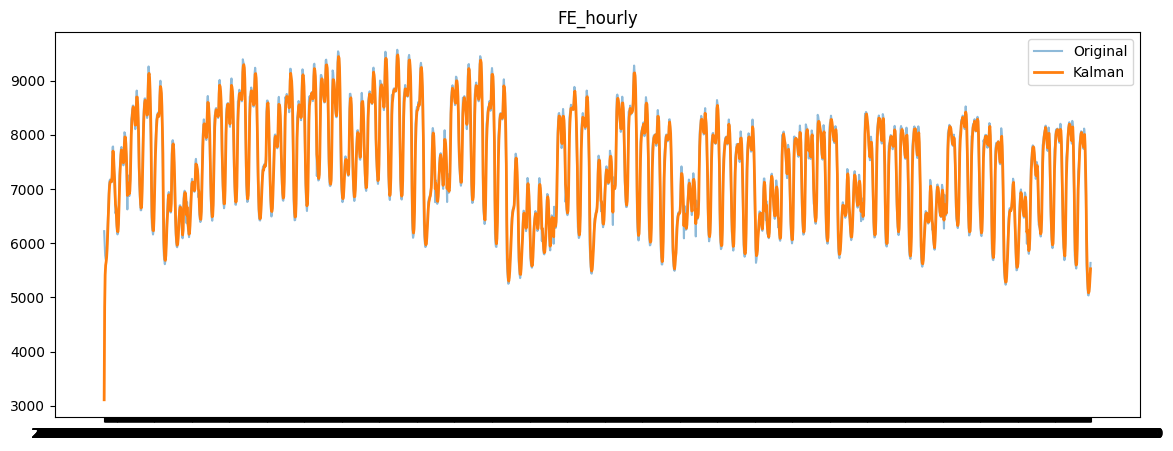

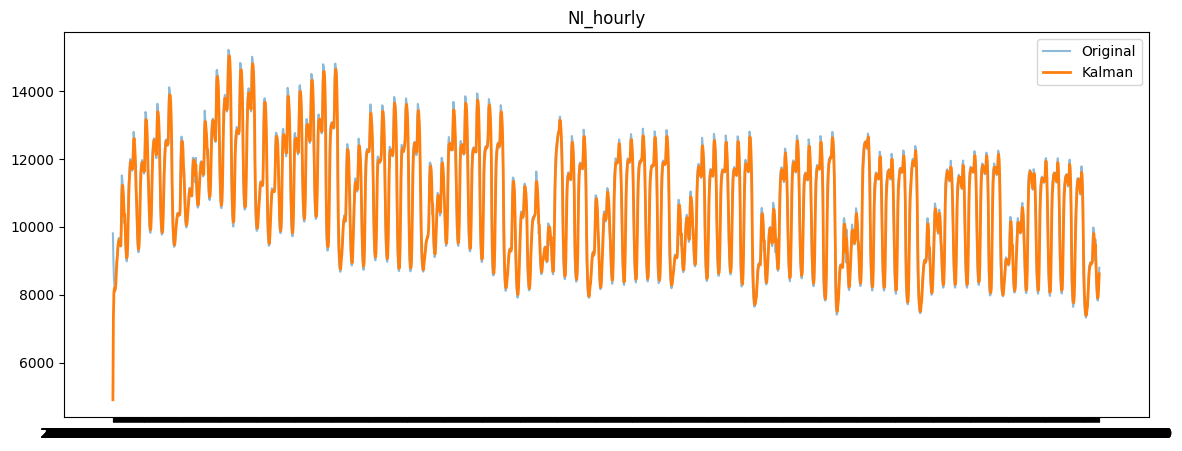

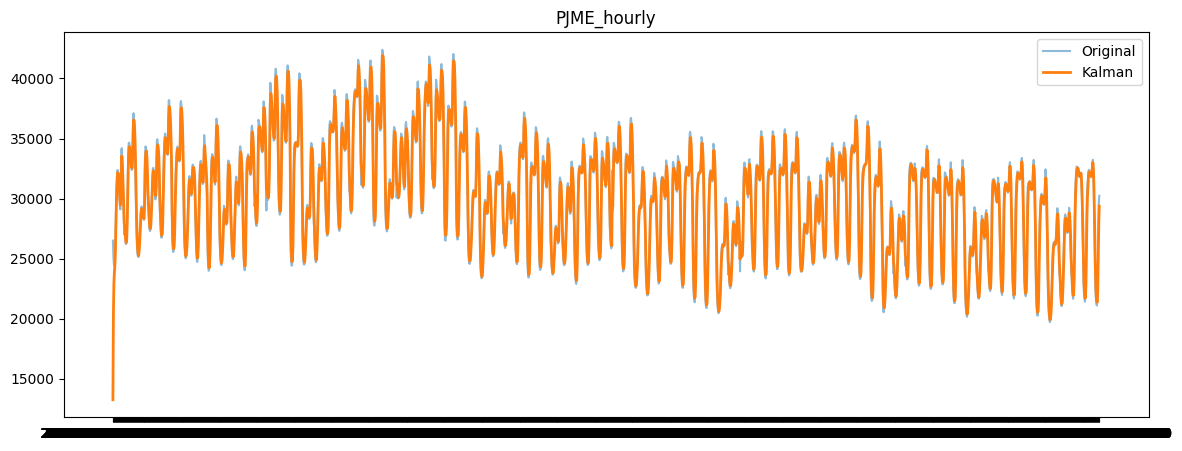

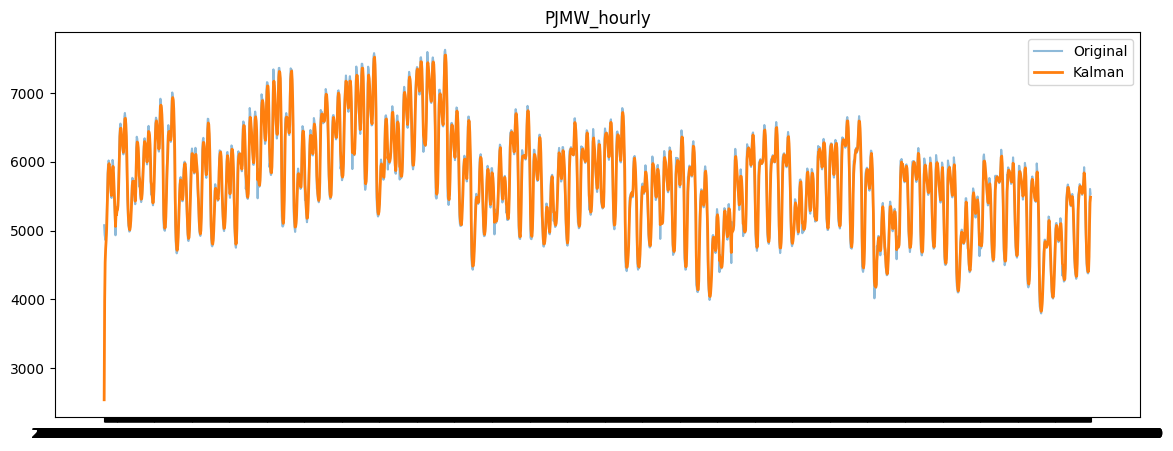

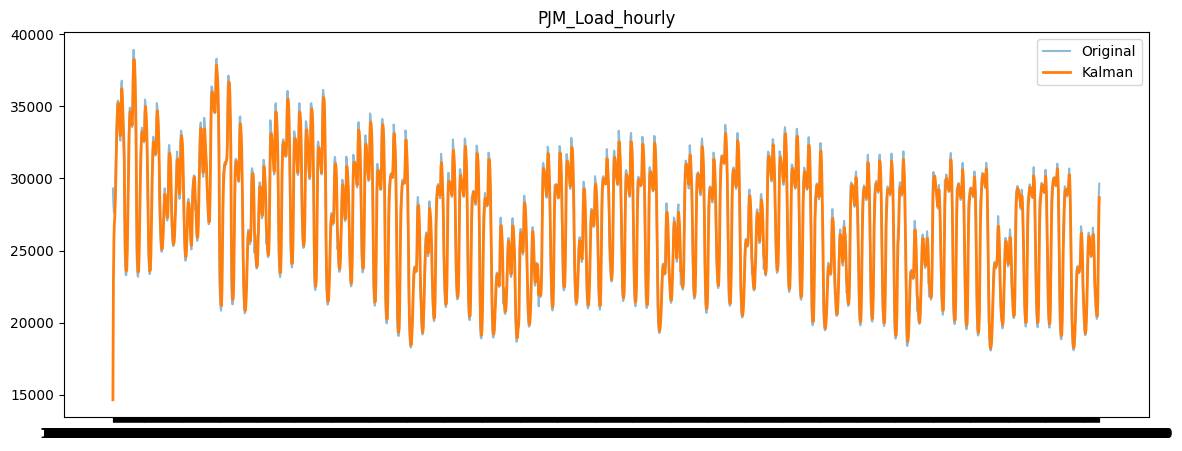

In [22]:
import matplotlib.pyplot as plt

for name, df in data_pool.items():

    plt.figure(figsize=(14,5))

    sample = df.iloc[:2000]  # 🔥 limit

    plt.plot(sample['ds'], sample['y'], label='Original', alpha=0.5)
    plt.plot(sample['ds'], sample['y_kalman'], label='Kalman', linewidth=2)

    plt.title(name)
    plt.legend()

    plt.show()


🚀 AEP_hourly processing...


15:04:04 - cmdstanpy - INFO - Chain [1] start processing
15:05:21 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:05:35,858] A new study created in memory with name: no-name-b0b2c9ff-de9f-4637-a656-a2a56f413669
[I 2026-04-16 15:05:36,627] Trial 0 finished with value: 694.4833228199192 and parameters: {'n_estimators': 418, 'max_depth': 5, 'learning_rate': 0.15452674157219987, 'subsample': 0.7531798330153845, 'colsample_bytree': 0.8473677199236624}. Best is trial 0 with value: 694.4833228199192.
[I 2026-04-16 15:05:38,130] Trial 1 finished with value: 696.4276995560871 and parameters: {'n_estimators': 862, 'max_depth': 5, 'learning_rate': 0.1708066770524845, 'subsample': 0.8550690520255638, 'colsample_bytree': 0.6421427949605912}. Best is trial 0 with value: 694.4833228199192.
[I 2026-04-16 15:05:39,413] Trial 2 finished with value: 697.8830196567933 and parameters: {'n_estimators': 923, 'max_depth': 4, 'learning_rate': 0.15581569212226434, 'subsample': 0.9941752576650162

Best iteration: 206

📊 AEP_hourly
Prophet -> MAE: 1305.2609, MAPE: 0.0852
Hybrid  -> MAE: 688.6371, MAPE: 0.0456

📊 SHAP Summary for AEP_hourly


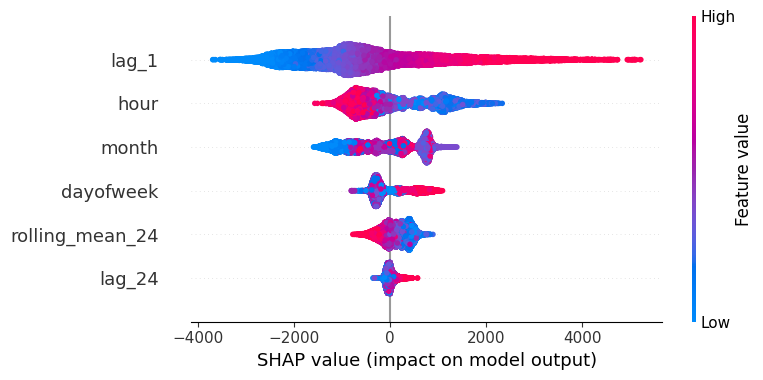


🚀 COMED_hourly processing...


15:06:11 - cmdstanpy - INFO - Chain [1] start processing
15:06:46 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:06:53,902] A new study created in memory with name: no-name-66884597-2b8f-4f3c-b997-55783aed1f9f
[I 2026-04-16 15:06:54,885] Trial 0 finished with value: 428.63536779708807 and parameters: {'n_estimators': 416, 'max_depth': 8, 'learning_rate': 0.06875635333569183, 'subsample': 0.7962053619555625, 'colsample_bytree': 0.8995994717328005}. Best is trial 0 with value: 428.63536779708807.
[I 2026-04-16 15:06:56,006] Trial 1 finished with value: 416.24775240693367 and parameters: {'n_estimators': 791, 'max_depth': 5, 'learning_rate': 0.03707517861772001, 'subsample': 0.638035864641992, 'colsample_bytree': 0.6765276402674357}. Best is trial 1 with value: 416.24775240693367.
[I 2026-04-16 15:06:57,312] Trial 2 finished with value: 422.5768477497602 and parameters: {'n_estimators': 682, 'max_depth': 7, 'learning_rate': 0.05607464283028794, 'subsample': 0.804232533253

Best iteration: 305

📊 COMED_hourly
Prophet -> MAE: 1030.1739, MAPE: 0.0902
Hybrid  -> MAE: 416.2401, MAPE: 0.0371

📊 SHAP Summary for COMED_hourly


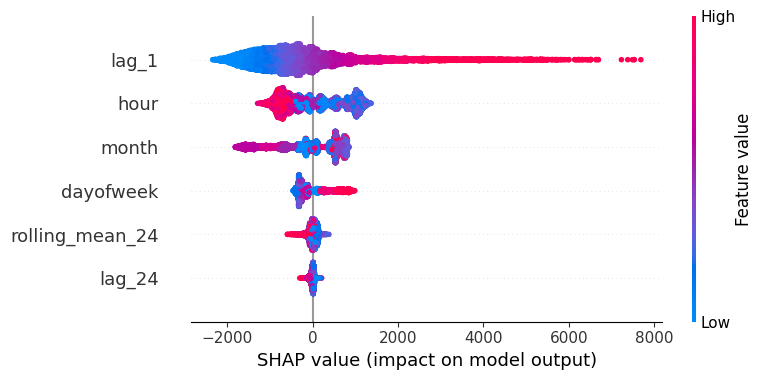


🚀 DAYTON_hourly processing...


15:07:21 - cmdstanpy - INFO - Chain [1] start processing
15:08:24 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:08:39,233] A new study created in memory with name: no-name-89c0f01b-bdfa-4a13-81bb-714df2407763
[I 2026-04-16 15:08:42,044] Trial 0 finished with value: 66.53612794282884 and parameters: {'n_estimators': 949, 'max_depth': 7, 'learning_rate': 0.034136672993049344, 'subsample': 0.7766763223924915, 'colsample_bytree': 0.9163533839811271}. Best is trial 0 with value: 66.53612794282884.
[I 2026-04-16 15:08:44,186] Trial 1 finished with value: 71.40119245598551 and parameters: {'n_estimators': 363, 'max_depth': 10, 'learning_rate': 0.16197036448024207, 'subsample': 0.8154888611728341, 'colsample_bytree': 0.8351122435680762}. Best is trial 0 with value: 66.53612794282884.
[I 2026-04-16 15:08:45,597] Trial 2 finished with value: 66.42327399015771 and parameters: {'n_estimators': 609, 'max_depth': 5, 'learning_rate': 0.19312873312665316, 'subsample': 0.7678136701565

Best iteration: 326

📊 DAYTON_hourly
Prophet -> MAE: 188.4786, MAPE: 0.0921
Hybrid  -> MAE: 66.9785, MAPE: 0.0331

📊 SHAP Summary for DAYTON_hourly


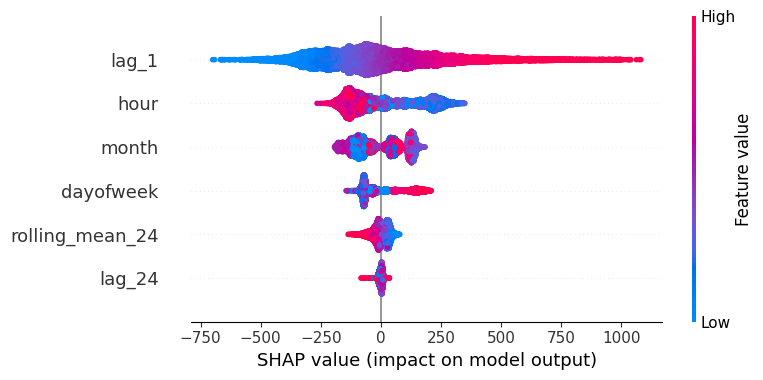


🚀 DEOK_hourly processing...


15:09:15 - cmdstanpy - INFO - Chain [1] start processing
15:09:38 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:09:44,609] A new study created in memory with name: no-name-ee6f506e-aca3-4a74-b829-8136aa805b44
[I 2026-04-16 15:09:45,703] Trial 0 finished with value: 117.09842189129618 and parameters: {'n_estimators': 636, 'max_depth': 7, 'learning_rate': 0.19261220088992864, 'subsample': 0.9460797308146551, 'colsample_bytree': 0.9835440016389463}. Best is trial 0 with value: 117.09842189129618.
[I 2026-04-16 15:09:46,680] Trial 1 finished with value: 111.4926514494912 and parameters: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.19028486695694724, 'subsample': 0.8356255541490556, 'colsample_bytree': 0.9932140803314953}. Best is trial 1 with value: 111.4926514494912.
[I 2026-04-16 15:09:47,180] Trial 2 finished with value: 109.29510030638544 and parameters: {'n_estimators': 415, 'max_depth': 5, 'learning_rate': 0.10983226396805443, 'subsample': 0.867024548606

Best iteration: 711

📊 DEOK_hourly
Prophet -> MAE: 317.3213, MAPE: 0.1033
Hybrid  -> MAE: 108.9386, MAPE: 0.0373

📊 SHAP Summary for DEOK_hourly


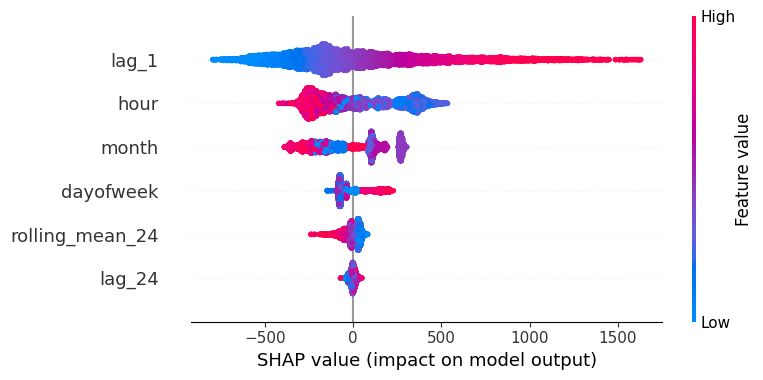


🚀 DOM_hourly processing...


15:10:13 - cmdstanpy - INFO - Chain [1] start processing
15:11:21 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:11:34,990] A new study created in memory with name: no-name-2198ce74-543b-4761-9b98-2793ea1b9d4e
[I 2026-04-16 15:11:36,432] Trial 0 finished with value: 431.51012120007096 and parameters: {'n_estimators': 395, 'max_depth': 9, 'learning_rate': 0.10788800617307474, 'subsample': 0.8461238614334982, 'colsample_bytree': 0.7936518765299594}. Best is trial 0 with value: 431.51012120007096.
[I 2026-04-16 15:11:37,037] Trial 1 finished with value: 546.6776273598207 and parameters: {'n_estimators': 397, 'max_depth': 3, 'learning_rate': 0.027686565564455888, 'subsample': 0.7697995558421862, 'colsample_bytree': 0.8121062008422695}. Best is trial 0 with value: 431.51012120007096.
[I 2026-04-16 15:11:38,036] Trial 2 finished with value: 426.9634069992723 and parameters: {'n_estimators': 622, 'max_depth': 4, 'learning_rate': 0.05843412878350921, 'subsample': 0.68559816068

Best iteration: 262

📊 DOM_hourly
Prophet -> MAE: 1324.5541, MAPE: 0.1143
Hybrid  -> MAE: 418.0436, MAPE: 0.0382

📊 SHAP Summary for DOM_hourly


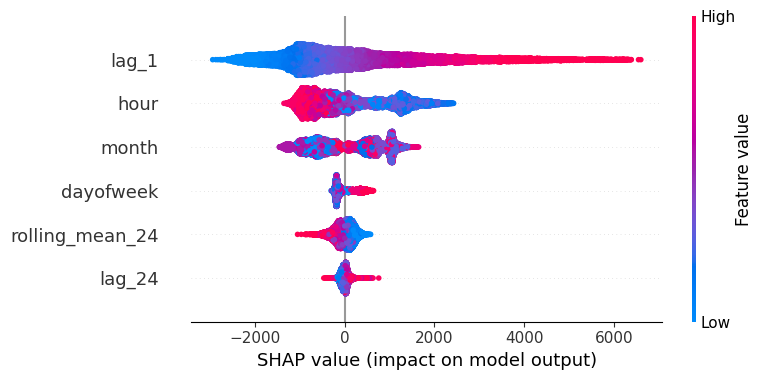


🚀 DUQ_hourly processing...


15:12:14 - cmdstanpy - INFO - Chain [1] start processing
15:13:19 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:13:32,979] A new study created in memory with name: no-name-f96fb245-84d8-429a-9332-88df95ad3e0a
[I 2026-04-16 15:13:34,051] Trial 0 finished with value: 77.58960075555946 and parameters: {'n_estimators': 304, 'max_depth': 9, 'learning_rate': 0.1756971949595903, 'subsample': 0.9313587586544305, 'colsample_bytree': 0.8555047225893403}. Best is trial 0 with value: 77.58960075555946.
[I 2026-04-16 15:13:38,781] Trial 1 finished with value: 78.78902221095795 and parameters: {'n_estimators': 951, 'max_depth': 10, 'learning_rate': 0.11811072539919548, 'subsample': 0.7490975199094351, 'colsample_bytree': 0.9848871378421257}. Best is trial 0 with value: 77.58960075555946.
[I 2026-04-16 15:13:39,911] Trial 2 finished with value: 78.12767422400317 and parameters: {'n_estimators': 314, 'max_depth': 8, 'learning_rate': 0.17079756657838485, 'subsample': 0.936699558215926

Best iteration: 520

📊 DUQ_hourly
Prophet -> MAE: 136.1273, MAPE: 0.0842
Hybrid  -> MAE: 74.2313, MAPE: 0.0463

📊 SHAP Summary for DUQ_hourly


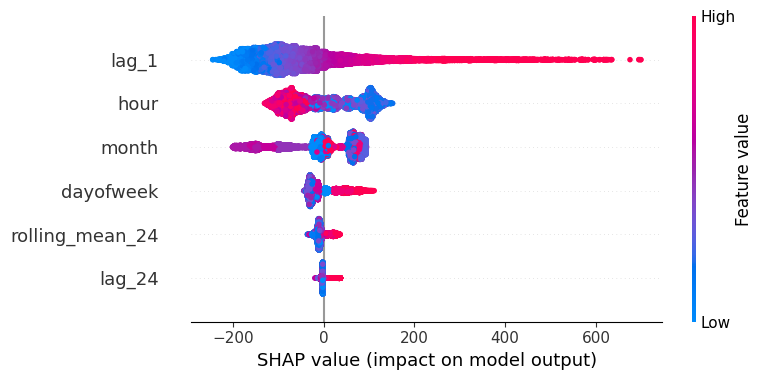


🚀 EKPC_hourly processing...


15:14:08 - cmdstanpy - INFO - Chain [1] start processing
15:14:25 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:14:30,106] A new study created in memory with name: no-name-0b21be0a-8e2c-4a0a-b1a3-31195daefc0e
[I 2026-04-16 15:14:32,702] Trial 0 finished with value: 88.17579853264792 and parameters: {'n_estimators': 857, 'max_depth': 9, 'learning_rate': 0.018193692387906427, 'subsample': 0.7924001090419084, 'colsample_bytree': 0.8504713861674251}. Best is trial 0 with value: 88.17579853264792.
[I 2026-04-16 15:14:33,193] Trial 1 finished with value: 86.1646993328937 and parameters: {'n_estimators': 312, 'max_depth': 5, 'learning_rate': 0.06881236409994798, 'subsample': 0.6004831969105454, 'colsample_bytree': 0.9984822461741305}. Best is trial 1 with value: 86.1646993328937.
[I 2026-04-16 15:14:35,603] Trial 2 finished with value: 91.79902512206374 and parameters: {'n_estimators': 863, 'max_depth': 9, 'learning_rate': 0.16242923052844743, 'subsample': 0.9032538344517437

Best iteration: 509

📊 EKPC_hourly
Prophet -> MAE: 227.7692, MAPE: 0.1492
Hybrid  -> MAE: 85.8279, MAPE: 0.0585

📊 SHAP Summary for EKPC_hourly


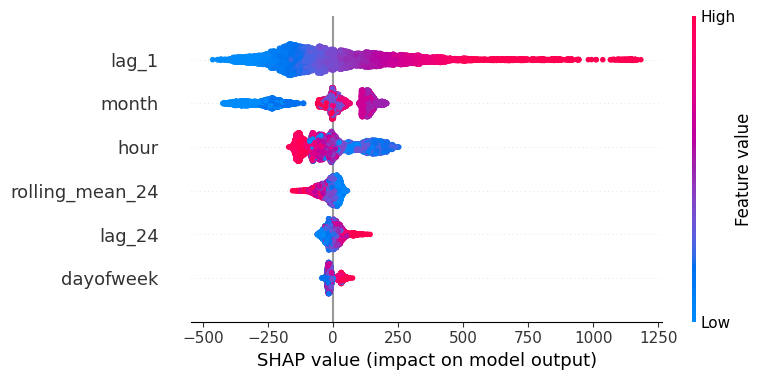


🚀 FE_hourly processing...


15:14:55 - cmdstanpy - INFO - Chain [1] start processing
15:15:18 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:15:25,995] A new study created in memory with name: no-name-052f3d4a-eb6b-4afb-988c-7bbbb41dc2eb
[I 2026-04-16 15:15:28,851] Trial 0 finished with value: 253.27844019641324 and parameters: {'n_estimators': 919, 'max_depth': 9, 'learning_rate': 0.17003715342250603, 'subsample': 0.8715287927653558, 'colsample_bytree': 0.7494785659181736}. Best is trial 0 with value: 253.27844019641324.
[I 2026-04-16 15:15:31,976] Trial 1 finished with value: 249.42549390713236 and parameters: {'n_estimators': 998, 'max_depth': 9, 'learning_rate': 0.16320151750640752, 'subsample': 0.911141961738732, 'colsample_bytree': 0.9356093720710574}. Best is trial 1 with value: 249.42549390713236.
[I 2026-04-16 15:15:34,599] Trial 2 finished with value: 239.724845090806 and parameters: {'n_estimators': 922, 'max_depth': 8, 'learning_rate': 0.05524190391622683, 'subsample': 0.8408143895024

Best iteration: 254

📊 FE_hourly
Prophet -> MAE: 620.0382, MAPE: 0.0795
Hybrid  -> MAE: 232.9693, MAPE: 0.0305

📊 SHAP Summary for FE_hourly


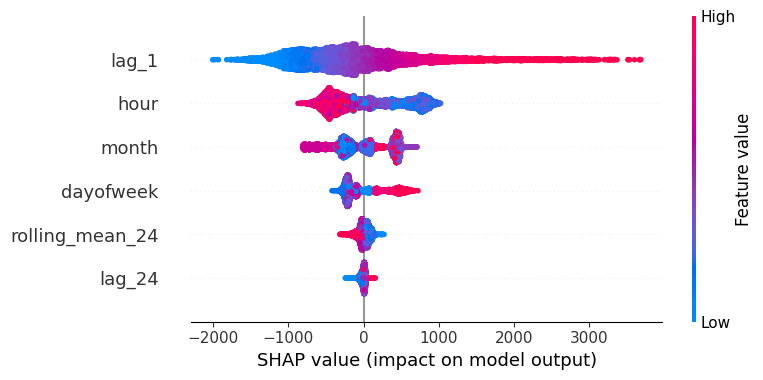


🚀 NI_hourly processing...


15:15:59 - cmdstanpy - INFO - Chain [1] start processing
15:16:30 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:16:36,755] A new study created in memory with name: no-name-0f5ebeac-ac1f-4def-b94c-cfaa48423e13
[I 2026-04-16 15:16:40,187] Trial 0 finished with value: 391.38294863609354 and parameters: {'n_estimators': 823, 'max_depth': 10, 'learning_rate': 0.04087159145850476, 'subsample': 0.6104067923718851, 'colsample_bytree': 0.973716821798095}. Best is trial 0 with value: 391.38294863609354.
[I 2026-04-16 15:16:41,443] Trial 1 finished with value: 373.6009743168107 and parameters: {'n_estimators': 812, 'max_depth': 5, 'learning_rate': 0.07918172916512041, 'subsample': 0.8020254429519792, 'colsample_bytree': 0.8699185596813817}. Best is trial 1 with value: 373.6009743168107.
[I 2026-04-16 15:16:42,875] Trial 2 finished with value: 373.6739293984044 and parameters: {'n_estimators': 919, 'max_depth': 4, 'learning_rate': 0.16300008388601864, 'subsample': 0.6536031644471

Best iteration: 483

📊 NI_hourly
Prophet -> MAE: 883.5104, MAPE: 0.0740
Hybrid  -> MAE: 370.8868, MAPE: 0.0320

📊 SHAP Summary for NI_hourly


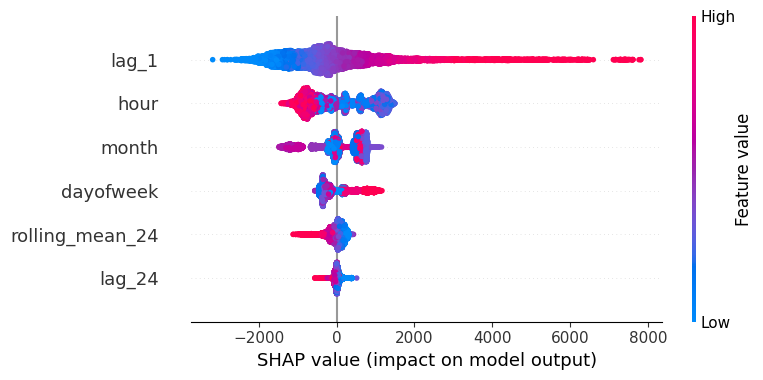


🚀 PJME_hourly processing...


15:17:11 - cmdstanpy - INFO - Chain [1] start processing
15:18:21 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 15:18:38,678] A new study created in memory with name: no-name-a842ec4e-7d5b-4d92-a716-e57fbacc8b12
[I 2026-04-16 15:18:43,377] Trial 0 finished with value: 1225.4248522570274 and parameters: {'n_estimators': 945, 'max_depth': 9, 'learning_rate': 0.15265550860345187, 'subsample': 0.6022720684016785, 'colsample_bytree': 0.9237717916000672}. Best is trial 0 with value: 1225.4248522570274.
[I 2026-04-16 15:18:47,159] Trial 1 finished with value: 1184.6386925662507 and parameters: {'n_estimators': 518, 'max_depth': 10, 'learning_rate': 0.031859791770463115, 'subsample': 0.9443577033709605, 'colsample_bytree': 0.7126435420344905}. Best is trial 1 with value: 1184.6386925662507.
[I 2026-04-16 15:18:49,186] Trial 2 finished with value: 1575.588389448141 and parameters: {'n_estimators': 762, 'max_depth': 3, 'learning_rate': 0.011640523194239782, 'subsample': 0.63198586

Best iteration: 148

📊 PJME_hourly
Prophet -> MAE: 3097.2331, MAPE: 0.0961
Hybrid  -> MAE: 1158.2591, MAPE: 0.0369

📊 SHAP Summary for PJME_hourly


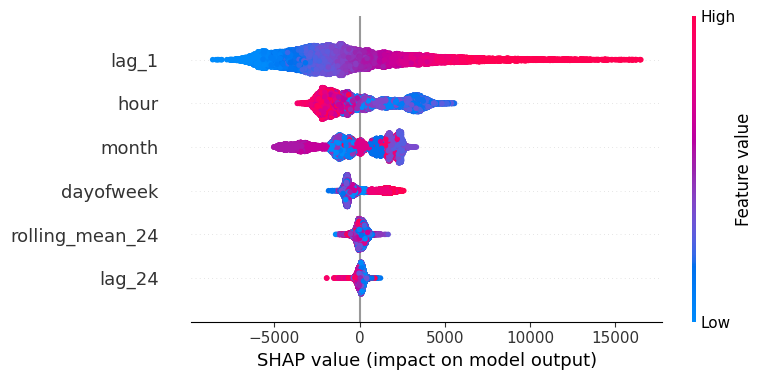


🚀 PJMW_hourly processing...


15:59:18 - cmdstanpy - INFO - Chain [1] start processing
16:00:05 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 16:00:17,185] A new study created in memory with name: no-name-e1c69db8-a0cd-411d-a12f-0a6b4b10be13
[I 2026-04-16 16:00:21,323] Trial 0 finished with value: 182.70331588409888 and parameters: {'n_estimators': 749, 'max_depth': 10, 'learning_rate': 0.19009432636317627, 'subsample': 0.7784444299858657, 'colsample_bytree': 0.6498556638673253}. Best is trial 0 with value: 182.70331588409888.
[I 2026-04-16 16:00:24,968] Trial 1 finished with value: 165.28782477212417 and parameters: {'n_estimators': 817, 'max_depth': 8, 'learning_rate': 0.10293856043841401, 'subsample': 0.8276267331946222, 'colsample_bytree': 0.7875091387974174}. Best is trial 1 with value: 165.28782477212417.
[I 2026-04-16 16:00:26,976] Trial 2 finished with value: 156.22690780038207 and parameters: {'n_estimators': 760, 'max_depth': 3, 'learning_rate': 0.1424737651522393, 'subsample': 0.6757131043

Best iteration: 220

📊 PJMW_hourly
Prophet -> MAE: 527.9988, MAPE: 0.0909
Hybrid  -> MAE: 161.5179, MAPE: 0.0286

📊 SHAP Summary for PJMW_hourly


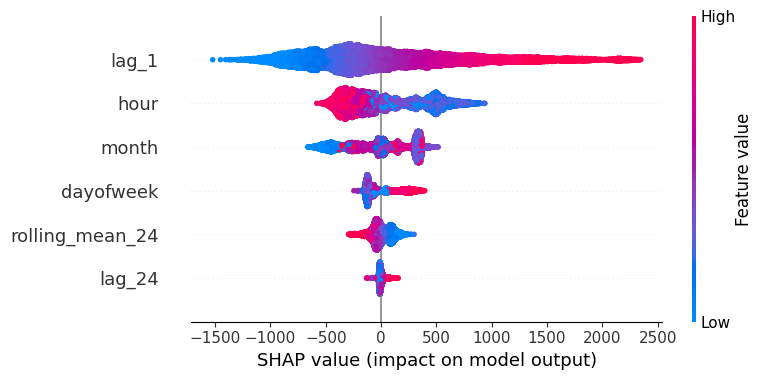


🚀 PJM_Load_hourly processing...


16:00:54 - cmdstanpy - INFO - Chain [1] start processing
16:01:13 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-16 16:01:17,041] A new study created in memory with name: no-name-7c58c115-ab89-4c1e-8304-4da8943e7d59
[I 2026-04-16 16:01:19,192] Trial 0 finished with value: 1292.9978563019836 and parameters: {'n_estimators': 914, 'max_depth': 9, 'learning_rate': 0.19618329221716055, 'subsample': 0.9977587698235456, 'colsample_bytree': 0.9166426271950077}. Best is trial 0 with value: 1292.9978563019836.
[I 2026-04-16 16:01:20,443] Trial 1 finished with value: 1253.157889749341 and parameters: {'n_estimators': 611, 'max_depth': 8, 'learning_rate': 0.04826671782058806, 'subsample': 0.9812739534773671, 'colsample_bytree': 0.9768994851617326}. Best is trial 1 with value: 1253.157889749341.
[I 2026-04-16 16:01:21,217] Trial 2 finished with value: 1211.9860877522783 and parameters: {'n_estimators': 711, 'max_depth': 5, 'learning_rate': 0.11364247837433993, 'subsample': 0.648898499978

Best iteration: 279

📊 PJM_Load_hourly
Prophet -> MAE: 2332.4410, MAPE: 0.0747
Hybrid  -> MAE: 1170.1609, MAPE: 0.0391

📊 SHAP Summary for PJM_Load_hourly


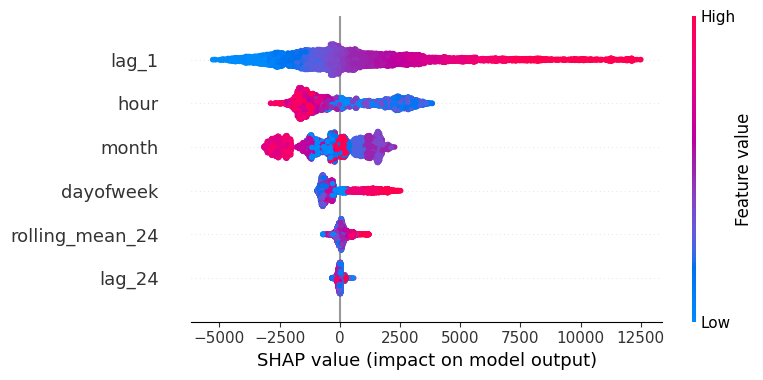

In [25]:
# =========================
# STORAGE
# =========================
all_forecasts = {}
performance_metrics = []

region_vars = data_pool.keys()

# =========================
# LOOP OVER DATASETS
# =========================
for var_name in region_vars:

    print(f"\n🚀 {var_name} processing...")

    # =========================
    # 1. DATA PREP
    # =========================
    df = data_pool[var_name].copy()
    df = df.iloc[24:].reset_index(drop=True)

    df['ds'] = pd.to_datetime(df['ds'])

    prophet_df = df[['ds', 'y_kalman']].rename(columns={'y_kalman': 'y'})

    # =========================
    # 2. PROPHET MODEL
    # =========================
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True
    )

    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=24*7, freq='h')
    forecast = model.predict(future)

    all_forecasts[var_name] = forecast

    # =========================
    # 3. MERGE (NO LEAKAGE HERE)
    # =========================
    merged = prophet_df.merge(
        forecast[['ds', 'yhat']],
        on='ds',
        how='left'
    )

    merged['residual'] = merged['y'] - merged['yhat']

    # =========================
    # 4. SPLIT (TIME BASED)
    # =========================
    split = int(len(merged) * 0.8)

    train = merged.iloc[:split].copy()
    test = merged.iloc[split:].copy()

    # =========================
    # 5. FEATURE ENGINEERING
    # =========================
    def create_features(df):
        df['hour'] = df['ds'].dt.hour
        df['dayofweek'] = df['ds'].dt.dayofweek
        df['month'] = df['ds'].dt.month

        df['lag_1'] = df['y'].shift(1)
        df['lag_24'] = df['y'].shift(24)
        df['rolling_mean_24'] = df['y'].rolling(24).mean()

        return df

    train = create_features(train)
    test = create_features(test)

    train = train.dropna()
    test = test.dropna()

    features = ['hour','dayofweek','month','lag_1','lag_24','rolling_mean_24']

    X_train = train[features]
    y_train = train['residual']

    X_test = test[features]
    y_test = test['residual']

    # =========================
    # 6. AUTOML (OPTUNA)
    # =========================
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": 42,
            "eval_metric": "mae",
            "tree_method": "hist"   # FIX CUDA ISSUE
        }

        model = XGBRegressor(**params)

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        return mean_absolute_error(y_test, preds)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=15)

    best_params = study.best_params

    # =========================
    # 7. FINAL XGBOOST MODEL
    # =========================
    xgb = XGBRegressor(
        **best_params,
        random_state=42,
        eval_metric='mae',
        tree_method="hist",
        device='cuda',
        early_stopping_rounds=10
    )

    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    print(f"Best iteration: {xgb.best_iteration}")

    # =========================
    # 8. HYBRID PREDICTION
    # =========================
    residual_pred = xgb.predict(X_test)

    test['hybrid_pred'] = test['yhat'] + residual_pred

    # =========================
    # 9. METRICS
    # =========================
    mae_prophet = mean_absolute_error(test['y'], test['yhat'])
    mape_prophet = mean_absolute_percentage_error(test['y'], test['yhat'])

    mae_hybrid = mean_absolute_error(test['y'], test['hybrid_pred'])
    mape_hybrid = mean_absolute_percentage_error(test['y'], test['hybrid_pred'])

    performance_metrics.append({
        'dataset': var_name,
        'MAE_Prophet': mae_prophet,
        'MAPE_Prophet': mape_prophet,
        'MAE_Hybrid': mae_hybrid,
        'MAPE_Hybrid': mape_hybrid
    })

    print(f"\n📊 {var_name}")
    print(f"Prophet -> MAE: {mae_prophet:.4f}, MAPE: {mape_prophet:.4f}")
    print(f"Hybrid  -> MAE: {mae_hybrid:.4f}, MAPE: {mape_hybrid:.4f}")

    # =========================
    # 10. SHAP (EXPLAINABILITY)
    # =========================
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test)

    print(f"\n📊 SHAP Summary for {var_name}")
    shap.summary_plot(shap_values, X_test)